# Case 1: 1st order in both Rxn 1 and Rxn 2

In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.special import expi

# Case 1: Numeric Solution (ODE)

In [ ]:
def reaction_system(t, C, k1, k2):
    C_A, C_B, C_C = C
    dC_A_dt = -k1 * C_A
    dC_B_dt = k1 * C_A - k2 * C_B
    dC_C_dt = k2 * C_B
    return [dC_A_dt, dC_B_dt, dC_C_dt]

# Initial conditions
C_A0 = 1.0  # mol/L
C_B0 = 0.0  # mol/L
C_C0 = 0.0  # mol/L
initial_conditions = [C_A0, C_B0, C_C0]

# Time span for the simulation
t_span = (0, 5)  # seconds
t_eval = np.linspace(t_span[0], t_span[1], 100)

k1 = 1
k2 = 1

solution = solve_ivp(
    reaction_system, t_span, initial_conditions, args=(k1, k2), t_eval=t_eval, method="RK45"
)

t = solution.t
C_A, C_B, C_C = solution.y

max_ind = np.argmax(C_B)
max_B_t = t[max_ind]
max_B = C_B[max_ind]

plt.scatter(max_B_t,max_B, marker='*', color='r', label='Max B',linewidths=3)
print(f'B max = {max_B:.3f} M at t={max_B_t:.3f} sec')

plt.plot(t, C_A, label="C_A (mol/L)")
plt.plot(t, C_B, label="C_B (mol/L)")
plt.plot(t, C_C, label="C_C (mol/L)")
plt.xlabel("Time (s)",fontsize=14)
plt.title(f"Case 1. Numeric Solution \nk1={k1}sec⁻¹, k2={k2}sec⁻¹ \ninitial condition={initial_conditions}",fontsize=14)
plt.ylabel("Concentration (mol/L)",fontsize=14)
plt.xlim(0,5)
plt.legend()

# Case 1: Analytic Solution

In [ ]:
k1 = 1
k2 = 1.001

t = np.linspace(0, 5, 100)
C_A = C_A0 * np.exp(-k1 * t)
C_B = k1*C_A0/(k2-k1)*(np.exp(-k1*t)-np.exp(-k2*t))
C_C = C_A0/(k2-k1)*(+k1*np.exp(-k2*t)-k2*np.exp(-k1*t)+k2-k1)

max_ind = np.argmax(C_B)
max_B_t = t[max_ind]
max_B = C_B[max_ind]

plt.scatter(max_B_t,max_B, marker='*', color='r', label='Max B',linewidths=3)
print(f'B max = {max_B:.3f} M at t={max_B_t:.3f} sec')

plt.plot(t, C_A, label="C_A (mol/L)")
plt.plot(t, C_B, label="C_B (mol/L)")
plt.plot(t, C_C, label="C_C (mol/L)")
plt.xlabel("Time (s)",fontsize=14)
plt.title(f"Case 1: Analytic Solution \n k1={k1}sec⁻¹, k2={k2}sec⁻¹ \n initial condition={initial_conditions}",fontsize=14)
plt.ylabel("Concentration (mol/L)",fontsize=14)
plt.xlim(0,5)
plt.legend()



# Case 1: Stochastic Solution

In [1]:
def Gillespie(k1,k2,rxn1_order,particle_nb):
    # Define stoichiometry matrix and reaction parameters
    stoichiometry_matrix = np.array([
        [-1,  1,  0],  # Reaction 1: A -> B
        [ 0, -1,  1]   # Reaction 2: B -> C
    ])
    
    # Parameters
    k1 = k1  # [=] 1/sec
    k2 = k2  # [=] 1/sec, Rate constant for B -> C
    
    # Unit conversion
    # Define initial particles first
    initial_counts = [particle_nb, 0, 0]  # [=] particles
    NA = 6.022e23  # Avogadro's number [=] particles/moles
    # Then define concentrations
    initial_concentrations = [1, 0, 0] # [=] moles/L
    # So can determine volume of the system
    volumes = [initial_counts[0]/(NA*initial_concentrations[0]), 0, 0] # [=] L
    
    # Define rate laws
    def rates(concent):  # Input should be a NumPy array
        concent = np.asarray(concent)
        A, B, C = concent
        return np.array([
            k1 * A ** rxn1_order,  # First-order reaction A -> B
            k2 * B                 # First-order reaction B -> C
        ])
    
    # Run Gillespie algorithm
    x = np.array(initial_counts, dtype=float) # variable
    t = 0
    times = [t]
    part = [x.copy()] # save history
    
    t_max = 5 # set the t_max of the interest so that reducing the computationing time
    while t < t_max :
        # Step 1: Compute reaction probabilities
        # unit conversion
        concent = x/(NA*volumes[0])
        reaction_rates = rates(concent)
        # print(reaction_rates)
        r_total = np.sum(reaction_rates[0]+reaction_rates[1])
        # print(r_total)
        if r_total <= 0:
            break
        
        # Step 2: Generate random numbers and calculate time step
        p1, p2 = np.random.uniform(0, 1, size=2)
        tau = -np.log(p1) / (r_total*NA*volumes[0])
        # why should r_total be devided by NA*volumes[0]:
        # gillespie reaction rate: r1 = k1*x_A [=] particles/sec
        # reaction rate of mine:   r1 = k1*C_A [=] moles/sec
        # so I should convert units so that times are not changing with the number of particles
        
        # Step 3: Determine which reaction occurs
        m = 1 if p2 > reaction_rates[0]/r_total else 0
        
        # Step 4: Update time and species counts
        t += tau
        x += stoichiometry_matrix[m]
        
        times.append(t)
        part.append(x.copy())
    
    # rescaling times
    times = np.array(times)
    part = np.array(part)
    concentrations = part/(NA*volumes[0])

    return times, concentrations, initial_concentrations

In [ ]:
k1 = 1 # [=] 1/sec
k2 = 1 # [=] 1/sec
rxn_order = 1
particle_nb = 10000
times, concentrations, initial_concentrations = Gillespie(k1,k2,rxn_order,particle_nb)

max_ind = np.argmax(concentrations[:,1])
max_B_t = times[max_ind]
max_B = concentrations[:,1][max_ind]
plt.scatter(max_B_t,max_B, marker='*', color='r', label='Max B',linewidths=3)
print(f'B max = {max_B:.3f} M at t={max_B_t:.3f} sec')

plt.plot(times, concentrations[:,0], label='C_A')
plt.plot(times, concentrations[:,1], label='C_B')
plt.plot(times, concentrations[:,2], label='C_C')
plt.xlim(0,5)
plt.xlabel('Time (s)',fontsize=14)
plt.ylabel('Concentration (M)',fontsize=14)
plt.title(f'Stochastic Solution for {rxn_order} order in first rxn \nk1={k1}sec⁻¹, k2={k2}sec⁻¹ \n initial condition={initial_conditions}',fontsize=14)
plt.legend()

# Case 2: 2nd order in Rxn 1 but still 1st order in Rxn 2

# Case 2: Numeric solution

In [ ]:
# Define the system of ODEs
def reaction_system(t, C, k1, k2):
    C_A, C_B, C_C = C
    dC_A_dt = -k1 * C_A **2
    dC_B_dt = k1 * C_A **2 - k2 * C_B
    dC_C_dt = k2 * C_B
    return [dC_A_dt, dC_B_dt, dC_C_dt]

# Initial conditions
C_A0 = 1.0  # mol/L
C_B0 = 0.0  # mol/L
C_C0 = 0.0  # mol/L
initial_conditions = [C_A0, C_B0, C_C0]

# Time span for the simulation
t_span = (0, 5)  # seconds
t_eval = np.linspace(t_span[0], t_span[1], 100)

k1=1
k2=1
solution = solve_ivp(reaction_system, t_span, initial_conditions, args=(k1, k2), t_eval=t_eval, method="RK45")
t = solution.t
C_A, C_B, C_C = solution.y

max_ind = np.argmax(C_B)
max_B_t = t[max_ind]
max_B = C_B[max_ind]

plt.scatter(max_B_t,max_B, marker='*', color='r', label='Max B',linewidths=3)
print(f'B max = {max_B:.3f} M at t={max_B_t:.3f} sec')

plt.plot(t, C_A, label="C_A (mol/L)")
plt.plot(t, C_B, label="C_B (mol/L)")
plt.plot(t, C_C, label="C_C (mol/L)")
plt.xlim(0,5)
plt.xlabel("Time (s)",fontsize=18)
plt.title(f'Case 2: Numeric Solution \nk1={k1}(Msec)⁻¹, k2={k2}sec⁻¹ \n initial condition={initial_conditions}',fontsize=14)
plt.ylabel("Concentration (mol/L)",fontsize=18)
plt.legend()
plt.show()

# Case 2: Analytic solution

In [ ]:
k1 = 1
k2 = 1.001

t = np.linspace(0, 5, 100)
C_A = C_A0 / (1+C_A0*k1*t)

# def C_B(t, C_A0, k1, k2):
#     factor = -np.exp(-k2 * t - k2 / (C_A0 * k1)) / (C_A0 * k1)
#     Ei_term = (1 / (1 + C_A0 * k1 * t)) + (k2 / (C_A0 * k1)) * expi(k2 * (1 + C_A0 * k1 * t) / (C_A0 * k1))
#     return factor * Ei_term
    
# C_B = C_B(t,C_A0, k1, k2)

# def C_C(t, C_A0, k1, k2):
#     # Exponential integral terms
#     Ei_t = expi(k2 * (1 + C_A0 * k1 * t) / (C_A0 * k1))
#     Ei_0 = expi(k2 / (C_A0 * k1))

#     # Compute C_C(t)
#     factor = np.exp(-k2 / (C_A0 * k1))
#     return factor * (Ei_t - Ei_0) * (1 - np.exp(-k2 * t))
    
# C_C = C_C(t, C_A0, k1, k2)

plt.plot(t, C_A, label="C_A (mol/L)")
# plt.plot(t, C_B, label="C_B (mol/L)")
# plt.plot(t, C_C, label="C_C (mol/L)")
plt.xlim(0,5)
plt.xlabel("Time (s)",fontsize=14)
plt.title(f"Case 2: Analytic Solution \nk1={k1}(Msec)⁻¹, k2={k2}sec⁻¹ \n initial condition={[C_A[0],0,0]}",fontsize=14)
plt.ylabel("Concentration (mol/L)",fontsize=14)
plt.legend()

In [ ]:
# import numpy as np
import matplotlib.pyplot as plt

# Parameters
C_A0 = 1  # Initial concentration of A (M)
k1 = 1    # Rate constant for A -> B
k2 = 1    # Rate constant for B -> C
t = np.linspace(0, 5, 100)  # Time range

# Analytical solutions
C_A = C_A0 / (1 + C_A0 * k1 * t)
C_B = (k1 * C_A0 * t / (1 + C_A0 * k1 * t)) * np.exp(-k2 * t)
C_C = 1 - ((1 + k1 * C_A0 * t + k2 * t) / (1 + k1 * C_A0 * t)) * np.exp(-k2 * t)

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(t, C_A, label="C_A (A)", linestyle='-', linewidth=2)
plt.plot(t, C_B, label="C_B (B)", linestyle='--', linewidth=2)
plt.plot(t, C_C, label="C_C (C)", linestyle='-.', linewidth=2)
plt.xlabel("Time (t)")
plt.ylabel("Concentration (M)")
plt.legend()
plt.title("Concentration Profiles Over Time")
plt.grid()
plt.show()

# Case 2: Stochastic solution

In [ ]:
k1 = 1 # [=] 1/sec
k2 = 1 # [=] 1/sec
rxn_order = 2
particle_nb = 10000
times, concentrations, initial_conditions = Gillespie(k1,k2,rxn_order,particle_nb)

max_ind = np.argmax(concentrations[:,1])
max_B_t = times[max_ind]
max_B = concentrations[:,1][max_ind]
plt.scatter(max_B_t,max_B, marker='*', color='r', label='Max B',linewidths=3)
print(f'B max = {max_B:.3f} M at t={max_B_t:.3f} sec')

plt.plot(times, concentrations[:,0], label='C_A')
plt.plot(times, concentrations[:,1], label='C_B')
plt.plot(times, concentrations[:,2], label='C_C')
plt.xlim(0,5)
plt.xlabel('Time (s)',fontsize=14)
plt.ylabel('Concentration (M)',fontsize=14)
plt.title(f'Case 2: Stochastic Solution \nk1={k1}(Msec)⁻¹, k2={k2}sec⁻¹ \n initial condition={initial_conditions}',fontsize=14)
plt.legend()

# rate vs time in case 1 vs case 2

In [ ]:
k1 = 1
k2 = 1

# case 1: Numeric
def reaction_system1(t, C, k1, k2):
    C_A, C_B, C_C = C
    dC_A_dt = -k1 * C_A
    dC_B_dt = k1 * C_A - k2 * C_B
    dC_C_dt = k2 * C_B
    return [dC_A_dt, dC_B_dt, dC_C_dt]

# Initial conditions
C_A0 = 1.0  # mol/L
C_B0 = 0.0  # mol/L
C_C0 = 0.0  # mol/L
initial_conditions = [C_A0, C_B0, C_C0]

# Time span for the simulation
t_span = (0, 5)  # seconds
t_eval = np.linspace(t_span[0], t_span[1], 100)

solution = solve_ivp(
    reaction_system1, t_span, initial_conditions, args=(k1, k2), t_eval=t_eval, method="RK45"
)

t1 = solution.t
C_A1, C_B1, C_C1 = solution.y

# case 2: Numeric
def reaction_system2(t, C, k1, k2):
    C_A, C_B, C_C = C
    dC_A_dt = -k1 * C_A **2
    dC_B_dt = k1 * C_A **2 - k2 * C_B
    dC_C_dt = k2 * C_B
    return [dC_A_dt, dC_B_dt, dC_C_dt]

k1=1
k2=1
solution = solve_ivp(reaction_system2, t_span, initial_conditions, args=(k1, k2), t_eval=t_eval, method="RK45")
t2 = solution.t
C_A2, C_B2, C_C2 = solution.y

# plot

dC_dt1 = -k1*C_A1
dC_dt2 = -k1*C_A2**2

plt.plot(t1,dC_dt1,label='rxn1')
plt.plot(t2,dC_dt2,label='rxn2')
plt.legend()


In [ ]:
plt.plot(t1,C_A1)
plt.plot(t2,C_A2)

# Sensitivity Analysis varying Initial Conditions w/ Numeric Solution

In [ ]:
def reaction_system(t, C, k1, k2):
    C_A, C_B, C_C = C
    dC_A_dt = -k1 * C_A
    dC_B_dt = k1 * C_A - k2 * C_B
    dC_C_dt = k2 * C_B
    return [dC_A_dt, dC_B_dt, dC_C_dt]

# Initial conditions
C_A0 = 10.0  # mol/L
C_B0 = 0.0  # mol/L
C_C0 = 0.0  # mol/L
initial_conditions = [C_A0, C_B0, C_C0]

# Time span for the simulation
t_span = (0, 5)  # seconds
t_eval = np.linspace(t_span[0], t_span[1], 100)

k1 = 1
k2 = 1

solution = solve_ivp(
    reaction_system, t_span, initial_conditions, args=(k1, k2), t_eval=t_eval, method="RK45"
)

t = solution.t
C_A, C_B, C_C = solution.y

max_ind = np.argmax(C_B)
max_B_t = t[max_ind]
max_B = C_B[max_ind]

plt.scatter(max_B_t,max_B, marker='*', color='r', label='Max B',linewidths=3)
print(f'B max = {max_B:.3f} M at t={max_B_t:.3f} sec')

plt.plot(t, C_A, label="C_A (mol/L)")
plt.plot(t, C_B, label="C_B (mol/L)")
plt.plot(t, C_C, label="C_C (mol/L)")
plt.xlabel("Time (s)",fontsize=14)
plt.title(f"Case 1. Numeric Solution \nk1={k1}sec⁻¹, k2={k2}sec⁻¹ \ninitial condition={initial_conditions}",fontsize=14)
plt.ylabel("Concentration (mol/L)",fontsize=14)
plt.xlim(0,5)
plt.legend()

In [ ]:
def reaction_system(t, C, k1, k2):
    C_A, C_B, C_C = C
    dC_A_dt = -k1 * C_A
    dC_B_dt = k1 * C_A - k2 * C_B
    dC_C_dt = k2 * C_B
    return [dC_A_dt, dC_B_dt, dC_C_dt]

# Initial conditions
C_A0 = 0.1  # mol/L
C_B0 = 0.0  # mol/L
C_C0 = 0.0  # mol/L
initial_conditions = [C_A0, C_B0, C_C0]

# Time span for the simulation
t_span = (0, 5)  # seconds
t_eval = np.linspace(t_span[0], t_span[1], 100)

k1 = 1
k2 = 1

solution = solve_ivp(
    reaction_system, t_span, initial_conditions, args=(k1, k2), t_eval=t_eval, method="RK45"
)

t = solution.t
C_A, C_B, C_C = solution.y

max_ind = np.argmax(C_B)
max_B_t = t[max_ind]
max_B = C_B[max_ind]

plt.scatter(max_B_t,max_B, marker='*', color='r', label='Max B',linewidths=3)
print(f'B max = {max_B:.3f} M at t={max_B_t:.3f} sec')

plt.plot(t, C_A, label="C_A (mol/L)")
plt.plot(t, C_B, label="C_B (mol/L)")
plt.plot(t, C_C, label="C_C (mol/L)")
plt.xlabel("Time (s)",fontsize=14)
plt.title(f"Case 1. Numeric Solution \nk1={k1}sec⁻¹, k2={k2}sec⁻¹ \ninitial condition={initial_conditions}",fontsize=14)
plt.ylabel("Concentration (mol/L)",fontsize=14)
plt.xlim(0,5)
plt.legend()

In [ ]:
# Define the system of ODEs
def reaction_system(t, C, k1, k2):
    C_A, C_B, C_C = C
    dC_A_dt = -k1 * C_A **2
    dC_B_dt = k1 * C_A **2 - k2 * C_B
    dC_C_dt = k2 * C_B
    return [dC_A_dt, dC_B_dt, dC_C_dt]

# Initial conditions
C_A0 = 10.0  # mol/L
C_B0 = 0.0  # mol/L
C_C0 = 0.0  # mol/L
initial_conditions = [C_A0, C_B0, C_C0]

# Time span for the simulation
t_span = (0, 5)  # seconds
t_eval = np.linspace(t_span[0], t_span[1], 100)

k1=1
k2=1
solution = solve_ivp(reaction_system, t_span, initial_conditions, args=(k1, k2), t_eval=t_eval, method="RK45")
t = solution.t
C_A, C_B, C_C = solution.y

max_ind = np.argmax(C_B)
max_B_t = t[max_ind]
max_B = C_B[max_ind]

plt.scatter(max_B_t,max_B, marker='*', color='r', label='Max B',linewidths=3)
print(f'B max = {max_B:.3f} M at t={max_B_t:.3f} sec')

plt.plot(t, C_A, label="C_A (mol/L)")
plt.plot(t, C_B, label="C_B (mol/L)")
plt.plot(t, C_C, label="C_C (mol/L)")
plt.xlim(0,5)
plt.xlabel("Time (s)",fontsize=18)
plt.title(f'Case 2: Numeric Solution \nk1={k1}(Msec)⁻¹, k2={k2}sec⁻¹ \n initial condition={initial_conditions}',fontsize=14)
plt.ylabel("Concentration (mol/L)",fontsize=18)
plt.legend()
plt.show()

In [ ]:
# Define the system of ODEs
def reaction_system(t, C, k1, k2):
    C_A, C_B, C_C = C
    dC_A_dt = -k1 * C_A **2
    dC_B_dt = k1 * C_A **2 - k2 * C_B
    dC_C_dt = k2 * C_B
    return [dC_A_dt, dC_B_dt, dC_C_dt]

# Initial conditions
C_A0 = 0.1  # mol/L
C_B0 = 0.0  # mol/L
C_C0 = 0.0  # mol/L
initial_conditions = [C_A0, C_B0, C_C0]

# Time span for the simulation
t_span = (0, 5)  # seconds
t_eval = np.linspace(t_span[0], t_span[1], 100)

k1=1
k2=1
solution = solve_ivp(reaction_system, t_span, initial_conditions, args=(k1, k2), t_eval=t_eval, method="RK45")
t = solution.t
C_A, C_B, C_C = solution.y

max_ind = np.argmax(C_B)
max_B_t = t[max_ind]
max_B = C_B[max_ind]

plt.scatter(max_B_t,max_B, marker='*', color='r', label='Max B',linewidths=3)
print(f'B max = {max_B:.3f} M at t={max_B_t:.3f} sec')

plt.plot(t, C_A, label="C_A (mol/L)")
plt.plot(t, C_B, label="C_B (mol/L)")
plt.plot(t, C_C, label="C_C (mol/L)")
plt.xlim(0,5)
plt.xlabel("Time (s)",fontsize=18)
plt.title(f'Case 2: Numeric Solution \nk1={k1}(Msec)⁻¹, k2={k2}sec⁻¹ \n initial condition={initial_conditions}',fontsize=14)
plt.ylabel("Concentration (mol/L)",fontsize=18)
plt.legend()
plt.show()

# Sensitivity Analysis varying k1 and k2 w/ Numeric Solution

In [ ]:
def reaction_system(t, C, k1, k2):
    C_A, C_B, C_C = C
    dC_A_dt = -k1 * C_A
    dC_B_dt = k1 * C_A - k2 * C_B
    dC_C_dt = k2 * C_B
    return [dC_A_dt, dC_B_dt, dC_C_dt]

# Initial conditions
C_A0 = 1.0  # mol/L
C_B0 = 0.0  # mol/L
C_C0 = 0.0  # mol/L
initial_conditions = [C_A0, C_B0, C_C0]

# Time span for the simulation
t_span = (0, 5)  # seconds
t_eval = np.linspace(t_span[0], t_span[1], 100)

k1 = 10
k2 = 1

solution = solve_ivp(
    reaction_system, t_span, initial_conditions, args=(k1, k2), t_eval=t_eval, method="RK45"
)

t = solution.t
C_A, C_B, C_C = solution.y

max_ind = np.argmax(C_B)
max_B_t = t[max_ind]
max_B = C_B[max_ind]

plt.scatter(max_B_t,max_B, marker='*', color='r', label='Max B',linewidths=3)
print(f'B max = {max_B:.3f} M at t={max_B_t:.3f} sec')

plt.plot(t, C_A, label="C_A (mol/L)")
plt.plot(t, C_B, label="C_B (mol/L)")
plt.plot(t, C_C, label="C_C (mol/L)")
plt.xlabel("Time (s)",fontsize=14)
plt.title(f"Case 1. Numeric Solution \nk1={k1}sec⁻¹, k2={k2}sec⁻¹ \ninitial condition={initial_conditions}",fontsize=14)
plt.ylabel("Concentration (mol/L)",fontsize=14)
plt.xlim(0,5)
plt.legend()

In [ ]:
def reaction_system(t, C, k1, k2):
    C_A, C_B, C_C = C
    dC_A_dt = -k1 * C_A
    dC_B_dt = k1 * C_A - k2 * C_B
    dC_C_dt = k2 * C_B
    return [dC_A_dt, dC_B_dt, dC_C_dt]

# Initial conditions
C_A0 = 1.0  # mol/L
C_B0 = 0.0  # mol/L
C_C0 = 0.0  # mol/L
initial_conditions = [C_A0, C_B0, C_C0]

# Time span for the simulation
t_span = (0, 5)  # seconds
t_eval = np.linspace(t_span[0], t_span[1], 100)

k1 = 1
k2 = 10

solution = solve_ivp(
    reaction_system, t_span, initial_conditions, args=(k1, k2), t_eval=t_eval, method="RK45"
)

t = solution.t
C_A, C_B, C_C = solution.y

max_ind = np.argmax(C_B)
max_B_t = t[max_ind]
max_B = C_B[max_ind]

plt.scatter(max_B_t,max_B, marker='*', color='r', label='Max B',linewidths=3)
print(f'B max = {max_B:.3f} M at t={max_B_t:.3f} sec')

plt.plot(t, C_A, label="C_A (mol/L)")
plt.plot(t, C_B, label="C_B (mol/L)")
plt.plot(t, C_C, label="C_C (mol/L)")
plt.xlabel("Time (s)",fontsize=14)
plt.title(f"Case 1. Numeric Solution \nk1={k1}sec⁻¹, k2={k2}sec⁻¹ \ninitial condition={initial_conditions}",fontsize=14)
plt.ylabel("Concentration (mol/L)",fontsize=14)
plt.xlim(0,5)
plt.legend()

In [ ]:
# Define the system of ODEs
def reaction_system(t, C, k1, k2):
    C_A, C_B, C_C = C
    dC_A_dt = -k1 * C_A **2
    dC_B_dt = k1 * C_A **2 - k2 * C_B
    dC_C_dt = k2 * C_B
    return [dC_A_dt, dC_B_dt, dC_C_dt]

# Initial conditions
C_A0 = 1.0  # mol/L
C_B0 = 0.0  # mol/L
C_C0 = 0.0  # mol/L
initial_conditions = [C_A0, C_B0, C_C0]

# Time span for the simulation
t_span = (0, 5)  # seconds
t_eval = np.linspace(t_span[0], t_span[1], 100)

k1=10
k2=1
solution = solve_ivp(reaction_system, t_span, initial_conditions, args=(k1, k2), t_eval=t_eval, method="RK45")
t = solution.t
C_A, C_B, C_C = solution.y

max_ind = np.argmax(C_B)
max_B_t = t[max_ind]
max_B = C_B[max_ind]

plt.scatter(max_B_t,max_B, marker='*', color='r', label='Max B',linewidths=3)
print(f'B max = {max_B:.3f} M at t={max_B_t:.3f} sec')

plt.plot(t, C_A, label="C_A (mol/L)")
plt.plot(t, C_B, label="C_B (mol/L)")
plt.plot(t, C_C, label="C_C (mol/L)")
plt.xlim(0,5)
plt.xlabel("Time (s)",fontsize=18)
plt.title(f'Case 2: Numeric Solution \nk1={k1}(Msec)⁻¹, k2={k2}sec⁻¹ \n initial condition={initial_conditions}',fontsize=14)
plt.ylabel("Concentration (mol/L)",fontsize=18)
plt.legend()
plt.show()

In [ ]:
# Define the system of ODEs
def reaction_system(t, C, k1, k2):
    C_A, C_B, C_C = C
    dC_A_dt = -k1 * C_A **2
    dC_B_dt = k1 * C_A **2 - k2 * C_B
    dC_C_dt = k2 * C_B
    return [dC_A_dt, dC_B_dt, dC_C_dt]

# Initial conditions
C_A0 = 1.0  # mol/L
C_B0 = 0.0  # mol/L
C_C0 = 0.0  # mol/L
initial_conditions = [C_A0, C_B0, C_C0]

# Time span for the simulation
t_span = (0, 5)  # seconds
t_eval = np.linspace(t_span[0], t_span[1], 100)

k1=1
k2=10
solution = solve_ivp(reaction_system, t_span, initial_conditions, args=(k1, k2), t_eval=t_eval, method="RK45")
t = solution.t
C_A, C_B, C_C = solution.y

max_ind = np.argmax(C_B)
max_B_t = t[max_ind]
max_B = C_B[max_ind]

plt.scatter(max_B_t,max_B, marker='*', color='r', label='Max B',linewidths=3)
print(f'B max = {max_B:.3f} M at t={max_B_t:.3f} sec')

plt.plot(t, C_A, label="C_A (mol/L)")
plt.plot(t, C_B, label="C_B (mol/L)")
plt.plot(t, C_C, label="C_C (mol/L)")
plt.xlim(0,5)
plt.xlabel("Time (s)",fontsize=18)
plt.title(f'Case 2: Numeric Solution \nk1={k1}(Msec)⁻¹, k2={k2}sec⁻¹ \n initial condition={initial_conditions}',fontsize=14)
plt.ylabel("Concentration (mol/L)",fontsize=18)
plt.legend()
plt.show()

B max = 0.603 M at t=0.288 sec


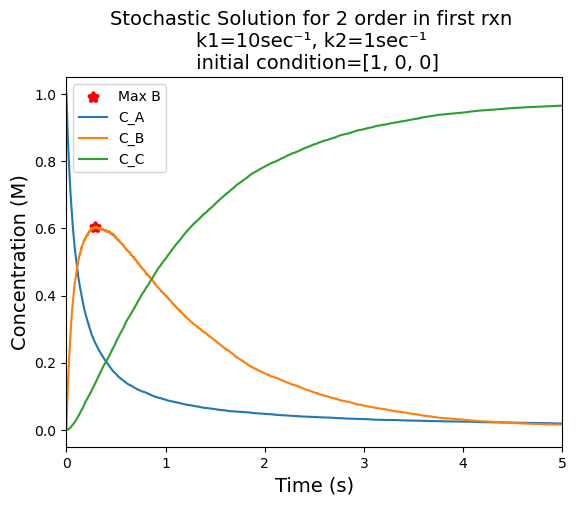

In [5]:
k1 = 10 # [=] 1/sec
k2 = 1 # [=] 1/sec
rxn_order = 2
particle_nb = 10000
times, concentrations, initial_concentrations = Gillespie(k1,k2,rxn_order,particle_nb)

max_ind = np.argmax(concentrations[:,1])
max_B_t = times[max_ind]
max_B = concentrations[:,1][max_ind]
plt.scatter(max_B_t,max_B, marker='*', color='r', label='Max B',linewidths=3)
print(f'B max = {max_B:.3f} M at t={max_B_t:.3f} sec')

plt.plot(times, concentrations[:,0], label='C_A')
plt.plot(times, concentrations[:,1], label='C_B')
plt.plot(times, concentrations[:,2], label='C_C')
plt.xlim(0,5)
plt.xlabel('Time (s)',fontsize=14)
plt.ylabel('Concentration (M)',fontsize=14)
plt.title(f'Stochastic Solution for {rxn_order} order in first rxn \nk1={k1}sec⁻¹, k2={k2}sec⁻¹ \n initial condition={initial_concentrations}',fontsize=14)
plt.legend()

B max = 0.072 M at t=0.194 sec


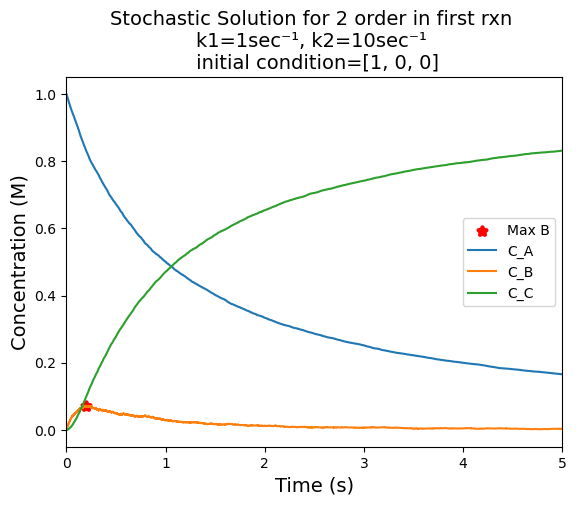

In [6]:
k1 = 1 # [=] 1/sec
k2 = 10 # [=] 1/sec
rxn_order = 2
particle_nb = 10000
times, concentrations, initial_concentrations = Gillespie(k1,k2,rxn_order,particle_nb)

max_ind = np.argmax(concentrations[:,1])
max_B_t = times[max_ind]
max_B = concentrations[:,1][max_ind]
plt.scatter(max_B_t,max_B, marker='*', color='r', label='Max B',linewidths=3)
print(f'B max = {max_B:.3f} M at t={max_B_t:.3f} sec')

plt.plot(times, concentrations[:,0], label='C_A')
plt.plot(times, concentrations[:,1], label='C_B')
plt.plot(times, concentrations[:,2], label='C_C')
plt.xlim(0,5)
plt.xlabel('Time (s)',fontsize=14)
plt.ylabel('Concentration (M)',fontsize=14)
plt.title(f'Stochastic Solution for {rxn_order} order in first rxn \nk1={k1}sec⁻¹, k2={k2}sec⁻¹ \n initial condition={initial_concentrations}',fontsize=14)
plt.legend()